In [5]:
import matplotlib.pyplot as plt  
from matplotlib import gridspec  
import pandas as pd
import numpy as np
# === Set Global Font Properties ===  
from matplotlib import rcParams  
from matplotlib.ticker import MaxNLocator  
import seaborn as sns  
import os  

# Set up matplotlib parameters to match Cell paper style  
rcParams['font.family'] = 'sans-serif'  
rcParams['font.sans-serif'] = ['Arial']  
rcParams['font.size'] = 5
rcParams['axes.linewidth'] = 0.8  
rcParams['xtick.major.width'] = 0.8  
rcParams['ytick.major.width'] = 0.8  
rcParams['xtick.major.size'] = 3  
rcParams['ytick.major.size'] = 3  
rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
rcParams['ps.fonttype'] = 42  
rcParams['svg.fonttype'] = 'none'  
rcParams['figure.dpi'] = 300   

In [6]:

# Global font size
FONT_SIZE = 12

time = ['2M', '4M']
library = ['ND', 'GW']

for t in time:
    for l in library:
        df1 = pd.read_csv(f'../new_mageck/Emx1-{l}-all_{t}/Emx1-{l}-all_{t}.gene_summary.txt', sep='\t', index_col=0)
        df1['gene'] = [i.split('_')[0] for i in df1.index.tolist()]
        df1['signed_score'] = df1.apply(lambda x: np.log10(x['neg|score']) if x['neg|lfc']<0 else -np.log10(x['pos|score']), axis=1)

        df2 = pd.read_csv(f'../new_mageck/Vgat-{l}-all_{t}/Vgat-{l}-all_{t}.gene_summary.txt', sep='\t',index_col=0)
        df2['gene'] = [i.split('_')[0] for i in df2.index.tolist()]
        df2['signed_score'] = df2.apply(lambda x: np.log10(x['neg|score']) if x['neg|lfc']<0 else -np.log10(x['pos|score']), axis=1)

        df3 = pd.read_csv(f'../new_mageck/Vglut2-{l}-all_{t}/Vglut2-{l}-all_{t}.gene_summary.txt', sep='\t',index_col=0)
        df3['gene'] = [i.split('_')[0] for i in df3.index.tolist()]
        df3['signed_score'] = df3.apply(lambda x: np.log10(x['neg|score']) if x['neg|lfc']<0 else -np.log10(x['pos|score']), axis=1)

        df4 = pd.read_csv(f'../new_mageck/Syn1-{l}-all_{t}/Syn1-{l}-all_{t}.gene_summary.txt', sep='\t',index_col=0)
        df4['gene'] = [i.split('_')[0] for i in df4.index.tolist()]
        df4['signed_score'] = df4.apply(lambda x: np.log10(x['neg|score']) if x['neg|lfc']<0 else -np.log10(x['pos|score']), axis=1)

        # Example gene sets  
        hits1 = set(df1[df1['hits'] == -1]['gene'])
        hits2 = set(df2[df2['hits'] == -1]['gene'])
        hits3 = set(df3[df3['hits'] == -1]['gene'])
        hits4 = set(df4[df4['hits'] == -1]['gene'])

        # Intersections  
        shared_1_2 = hits1 & hits2  
        shared_1_3 = hits1 & hits3 
        shared_1_4 = hits1 & hits4 
        shared_2_3 = hits2 & hits3  
        shared_2_4 = hits2 & hits4  
        shared_3_4 = hits3 & hits4  
        shared_all = hits1 & hits2 & hits3 & hits4 

        # Bars and matrix  
        bar_labels = [  
            'Screen1', 'Screen2', 'Screen3',  'Screen4',
            'Screen1 &\nScreen2', 'Screen1 &\nScreen3', 'Screen1 &\nScreen4',
            'Screen2 &\nScreen3',  'Screen2 &\nScreen4', 'Screen3 &\nScreen4',
            'All screens'  
        ]  
        bar_counts = [  
            len(hits1), len(hits2), len(hits3),  len(hits4), 
            len(shared_1_2), len(shared_1_3), len(shared_1_4),
            len(shared_2_3),  len(shared_2_4), len(shared_3_4),
            len(shared_all)  
        ]  
        bar_matrix = [  
            [1,0,0,0],  # Screen1  
            [0,1,0,0],  # Screen2  
            [0,0,1,0],  # Screen3  
            [0,0,0,1],  # Screen4  
            [1,1,0,0],  # 1&2  
            [1,0,1,0],  # 1&3  
            [1,0,0,1],  # 1&4  
            [0,1,1,0],  # 2&3
            [0,1,0,1],  # 2&4  
            [0,0,1,1],  # 3&4  
            [1,1,1,1],  # all  
        ]  
        screen_labels = ['Emx1', 'Vgat', 'Vglut2', 'Syn1']  
        cell_blue = "#3C5488FF"

        fig = plt.figure(figsize=(4,5))  
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.03)  

        # --- Top: Bar chart ---  
        ax_bar = fig.add_subplot(gs[0])   
        bars = ax_bar.bar(range(len(bar_counts)), bar_counts, color=cell_blue, zorder=2.5, edgecolor='k',  
                    linewidth=0.5,  
                    alpha=1,  
                    width=0.8 )  

        # Annotate bar heights (y-axis values) on top of each bar (font size 12)
        max_height = max(bar_counts) if bar_counts else 0
        for idx, bar in enumerate(bars):
            height = bar.get_height()
            y_pos = height + (max_height * 0.02 if max_height > 0 else height * 0.05)
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                y_pos,
                str(int(height)),
                ha='center',
                va='bottom',
                fontsize=FONT_SIZE
            )

        ax_bar.set_xticks(range(len(bar_counts)))  
        ax_bar.set_ylabel('Number of Hits', fontsize=FONT_SIZE)  
        ax_bar.tick_params(axis='both', which='major', labelsize=FONT_SIZE)
        ax_bar.spines['bottom'].set_visible(True)  
        ax_bar.spines['top'].set_visible(True)  
        ax_bar.spines['right'].set_visible(True)  
        ax_bar.spines['left'].set_linewidth(1.2)  
        plt.grid(True, axis='y', linestyle='--', alpha=0.5, color='grey')  

        # --- Bottom: Dot matrix ---  
        ax_dots = fig.add_subplot(gs[1])  
        dot_height = 0.5
        active_dot_kwargs = {'color': 'k', 'marker': 'o', 'markersize': 8, 'zorder': 11}  
        inactive_dot_kwargs = {'markerfacecolor': 'white', 'markeredgecolor': 'black', 'marker': 'o', 'markersize': 8, 'zorder': 11}  

        for i, dots in enumerate(bar_matrix):  
            y_filled = []  
            for j in range(4):  
                x, y = i, -j * dot_height  
                if dots[j]:  
                    ax_dots.plot(x, y, **active_dot_kwargs)  
                    y_filled.append(y)  
                else:  
                    ax_dots.plot(x, y, **inactive_dot_kwargs)  
            if len(y_filled) > 1:  
                ax_dots.plot([i, i], [min(y_filled), max(y_filled)], color='black', linewidth=2, zorder=10)  

        ax_dots.set_yticks([-k*dot_height for k in range(4)])  
        ax_dots.set_yticklabels(screen_labels, fontsize=FONT_SIZE)  
        ax_dots.set_ylim(-4 * dot_height, 0.7 * dot_height)  
        ax_dots.set_xlim(-0.5, len(bar_counts)-0.5)  
        ax_dots.spines['left'].set_visible(False)  
        ax_dots.spines['right'].set_visible(False)  
        ax_dots.spines['bottom'].set_visible(False)  
        ax_dots.spines['top'].set_visible(False)  
        ax_dots.tick_params(axis='y', length=0, labelsize=FONT_SIZE)  
        ax_dots.tick_params(axis='x', length=0)  
        ax_dots.set_xticks([])  

        # Adequate bottom margin so nothing is truncated  
        plt.subplots_adjust(left=0.1, right=0.99, top=0.92, bottom=0.3)  

        plt.savefig(f'../comparison/emx1_vglut2_vgat/syn1_Emx1_vs_vlut2_vs_vgat_{l}_{t}.pdf', bbox_inches = 'tight')
        plt.close(fig)

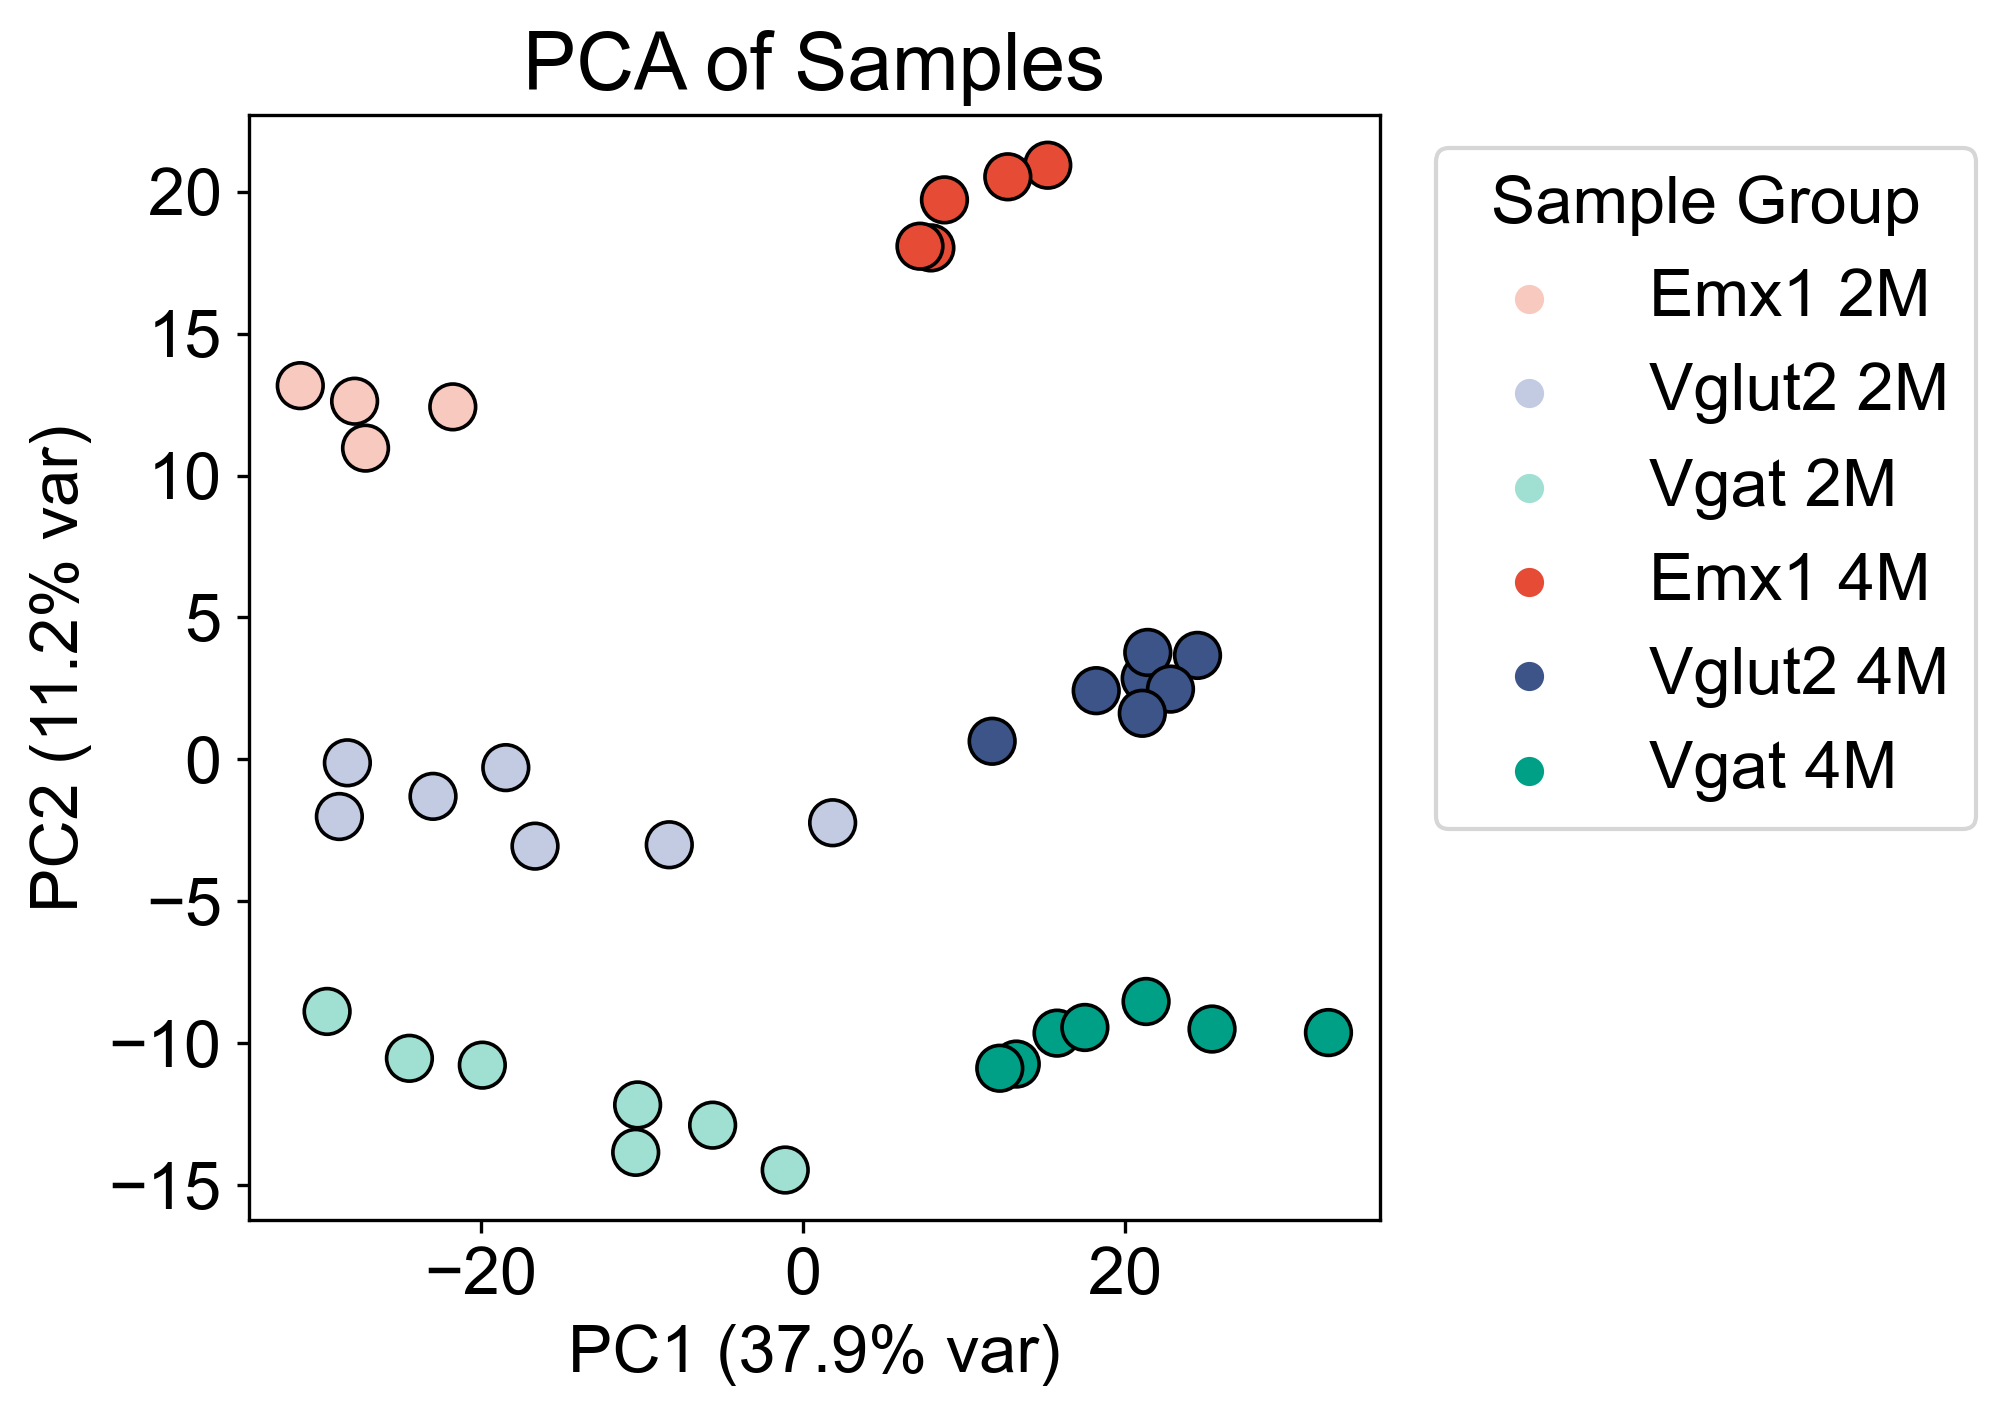

In [2]:
top_n = 50


df_emx1 = pd.read_csv('../new_mageck/Emx1-GW-all_4M/Emx1-GW-all_4M.gene_summary.txt', sep = '\t')
df_emx12 = pd.read_csv('../new_mageck/Emx1-GW-all_2M/Emx1-GW-all_2M.gene_summary.txt', sep = '\t')

# df_emx1 = df_emx1.iloc[:top_n,]
hits1 = df_emx1[df_emx1['hits'] == -1]['id'].tolist() + df_emx12[df_emx12['hits'] == -1]['id'].tolist()

df_vglut2 = pd.read_csv('../new_mageck/Vglut2-GW-all_4M/Vglut2-GW-all_4M.gene_summary.txt', sep = '\t')
df_vglut22 = pd.read_csv('../new_mageck/Vglut2-GW-all_2M/Vglut2-GW-all_2M.gene_summary.txt', sep = '\t')

# df_vglut2 = df_vglut2.iloc[:top_n,]

hits2 = df_vglut2[df_vglut2['hits'] == -1]['id'].tolist() + df_vglut22[df_vglut22['hits'] == -1]['id'].tolist()

df_vgat = pd.read_csv('../new_mageck/Vgat-GW-all_4M/Vgat-GW-all_4M.gene_summary.txt', sep = '\t')
df_vgat2 = pd.read_csv('../new_mageck/Vgat-GW-all_2M/Vgat-GW-all_2M.gene_summary.txt', sep = '\t')

# df_vgat = df_vgat.iloc[:top_n,]


hits3 = df_vgat[df_vgat['hits'] == -1]['id'].tolist() + df_vgat2[df_vgat2['hits'] == -1]['id'].tolist()


# genes = list(set(df_emx1['id'].tolist()[:] + df_vglut2['id'].tolist()[:] +  df_vgat['id'].tolist()[:]))
# genes = list(set(hits1) - (set(hits2) | set(hits3) )) + \
# list(set(hits2) - (set(hits1) | set(hits3) )) + \
# list(set(hits3) - (set(hits1) | set(hits2) ))
genes = list(set(hits1 + hits2 + hits3))

# genes = 

mageck_path = '../roc_auc/mageck_output/'
emx1_2M_files = []
vglut2_2M_files = []
vgat_2M_files = []

emx1_4M_files = []
vglut2_4M_files = []
vgat_4M_files = []

for sample in os.listdir(mageck_path):
    if 'Emx1-GW-4M' in sample:
        emx1_4M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
    elif 'Vglut2-GW-4M' in sample:
        vglut2_4M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
    elif 'Vgat-GW-4M' in sample:
        vgat_4M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
    elif 'Emx1-GW-2M' in sample:
        emx1_2M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
    elif 'Vglut2-GW-2M' in sample:
        vglut2_2M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
    elif 'Vgat-GW-2M' in sample:
        vgat_2M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
        



def load_lfc_each_rep(files, genes, lfc_col='log Score', gene_col='id', prefix=''):  
    dfs = []  
    for i, file in enumerate(files, 1):  
        df = pd.read_csv(file, sep = '\t')  
        df['log Score'] = np.log10(df['neg|score'])
        df = df[df['id'].isin(genes)][[gene_col, lfc_col]].set_index(gene_col)  
        # Label columns with timepoint and replicate number  
        label = f'{prefix}_rep{i}'  
        df.columns = [label]  
        dfs.append(df)  
    return dfs  

# ==== 2. Load Data, Don’t Average ====  
dfs_emx1_2M = load_lfc_each_rep(emx1_2M_files, genes, prefix='Emx1 2M')  
dfs_vglut2_2M = load_lfc_each_rep(vglut2_2M_files, genes, prefix='Vglut2 2M') 
dfs_vgat_2M = load_lfc_each_rep(vgat_2M_files, genes, prefix='Vgat 2M') 

dfs_emx1_4M = load_lfc_each_rep(emx1_4M_files, genes, prefix='Emx1 4M')  
dfs_vglut2_4M = load_lfc_each_rep(vglut2_4M_files, genes, prefix='Vglut2 4M') 
dfs_vgat_4M = load_lfc_each_rep(vgat_4M_files, genes, prefix='Vgat 4M') 

heatmap_df = pd.concat(dfs_emx1_2M + dfs_vglut2_2M + dfs_vgat_2M + dfs_emx1_4M + dfs_vglut2_4M + dfs_vgat_4M , axis=1)


import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.decomposition import PCA  
rcParams['font.family'] = 'sans-serif'  
rcParams['font.sans-serif'] = ['Arial']  
rcParams['font.size'] = 16
rcParams['axes.linewidth'] = 0.8  
rcParams['xtick.major.width'] = 0.8  
rcParams['ytick.major.width'] = 0.8  
rcParams['xtick.major.size'] = 3  
rcParams['ytick.major.size'] = 3  
rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
rcParams['ps.fonttype'] = 42  


# --- Transpose for PCA: features=samples ---  
X = heatmap_df.T  # shape: (samples, genes)  

# --- Run PCA ---  
pca = PCA(n_components=2)  
PCs = pca.fit_transform(X)  
pca_df = pd.DataFrame(PCs, columns=['PC1', 'PC2'], index=X.index)  

# Map group colors, as in your heatmap  
sample_groups = [col.split('_')[0] for col in X.index]  
group_palette = {  
    "Emx1 4M": "#E64B35FF",  # redish  
    "Vglut2 4M": "#3C5488FF",  # blueish  
    "Vgat 4M": "#00A087FF",   # greenish  ,
     "Emx1 2M": "#F8C9BF",  # redish  
    "Vglut2 2M": "#C3CBE3",  # blueish  
    "Vgat 2M": "#A0E0D2"   # greenish  
}  

group_colors = pd.Series(sample_groups, index=X.index).map(group_palette)  

# --- Plot ---  
plt.figure(figsize=(7, 5))  
sns.scatterplot(  
    x='PC1', y='PC2', data=pca_df,  
    hue=sample_groups,  
    palette=group_palette,  
    s=120, edgecolor='black'  
)  
plt.title('PCA of Samples')  
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')  
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')  
plt.legend(title='Sample Group', bbox_to_anchor=(1.02,1), loc='upper left')  
plt.tight_layout()  
plt.savefig('../comparison/emx1_vglut2_vgat/GW_PCA_union_hits.pdf', bbox_inches = 'tight')
plt.savefig('../comparison/emx1_vglut2_vgat/GW_PCA_union_hits.png', bbox_inches = 'tight', dpi=300)

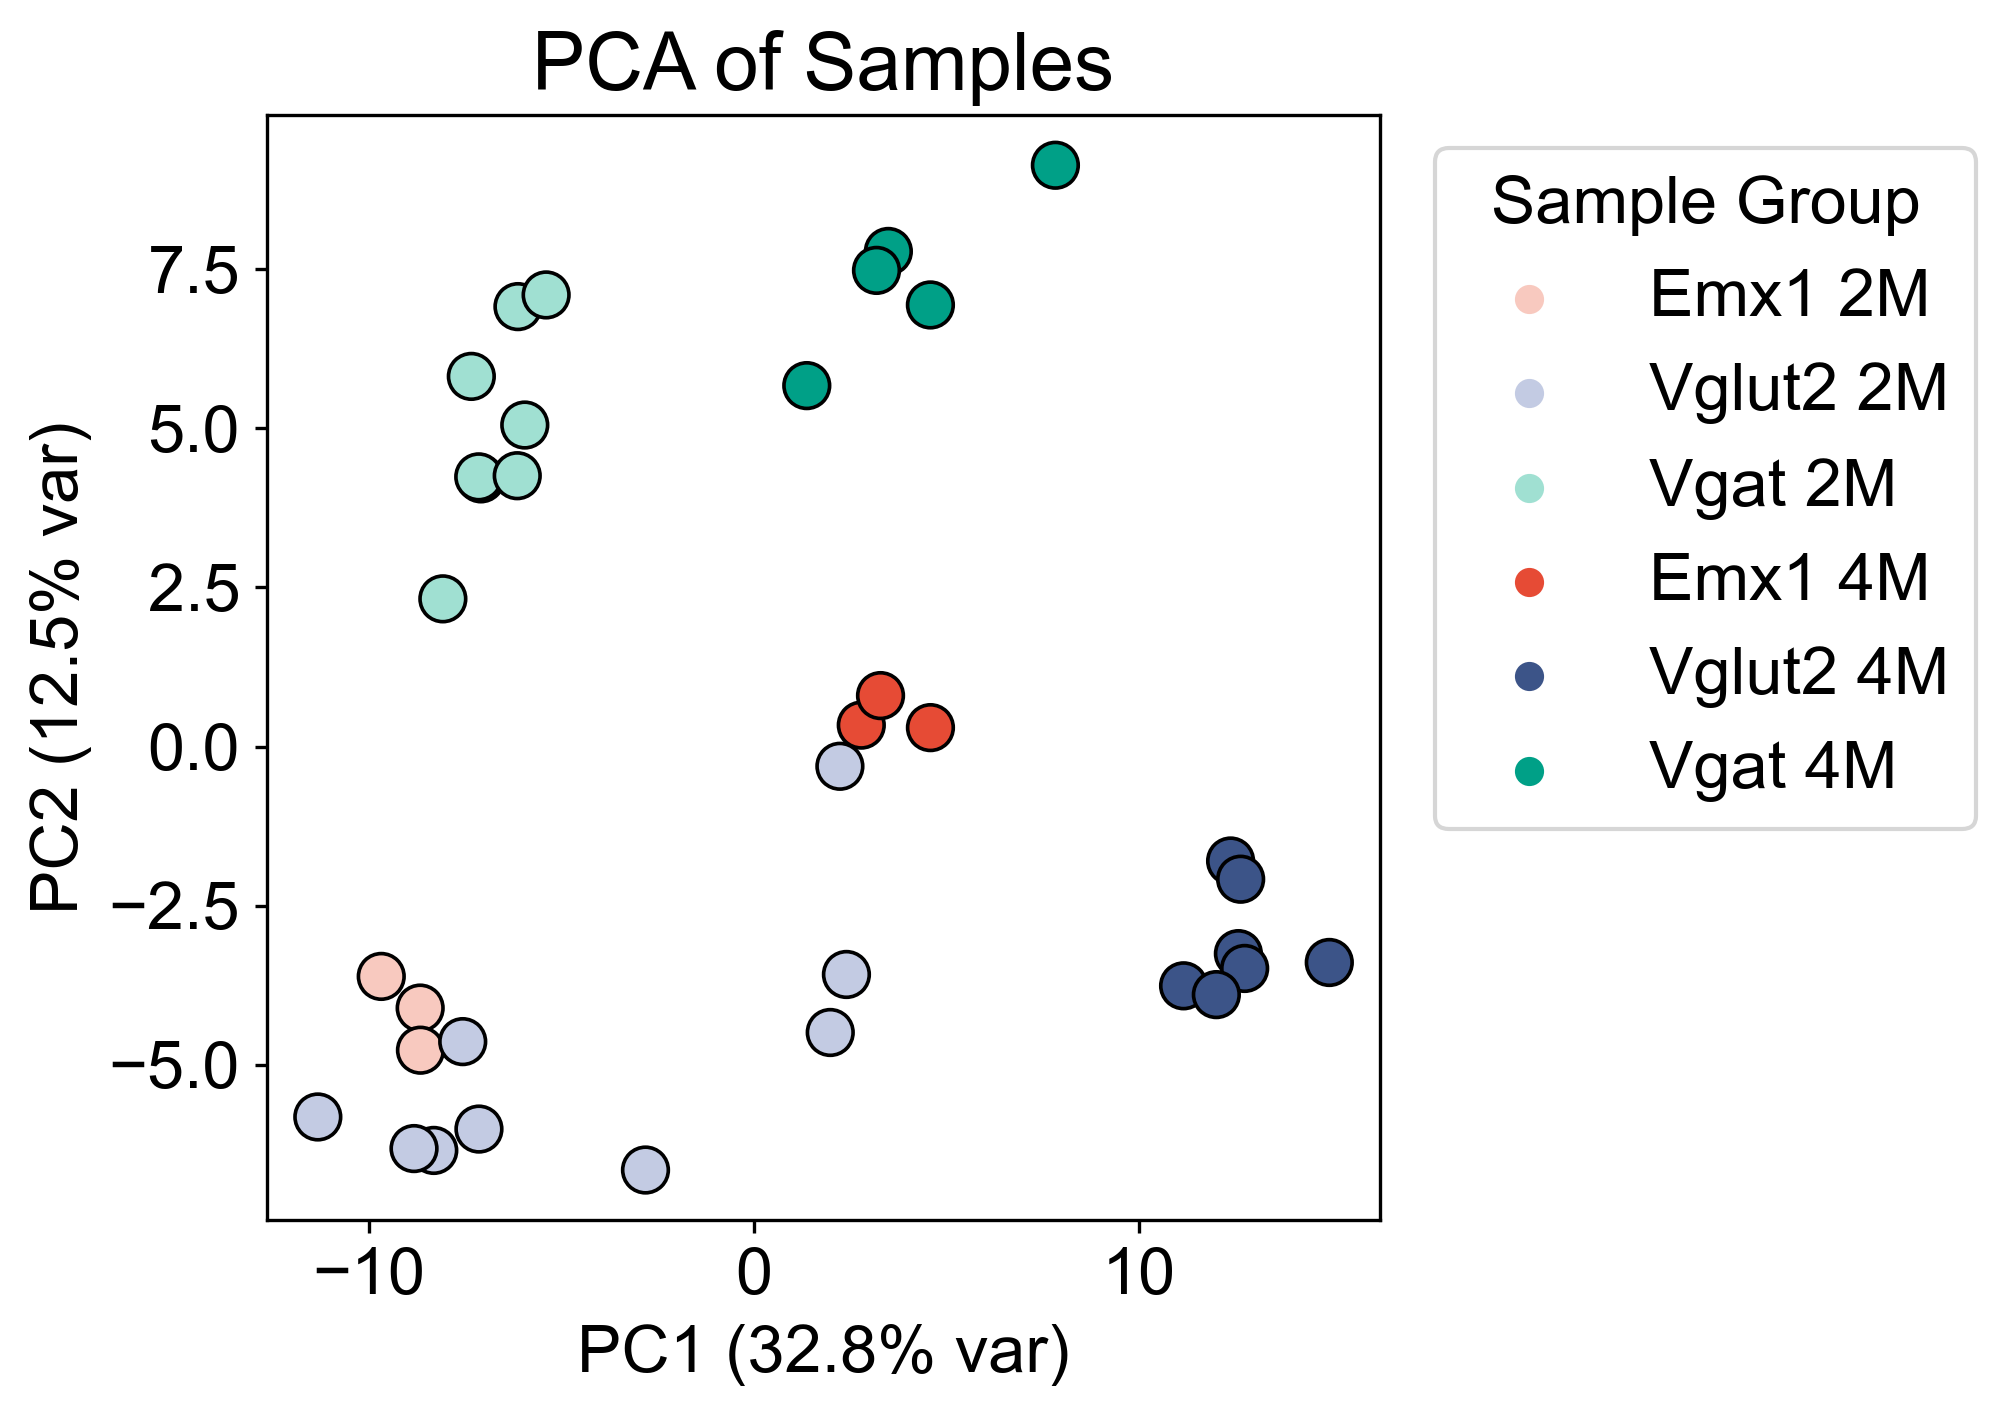

In [3]:
top_n = 50


df_emx1 = pd.read_csv('../new_mageck/Emx1-ND-all_4M/Emx1-ND-all_4M.gene_summary.txt', sep = '\t')
df_emx12 = pd.read_csv('../new_mageck/Emx1-ND-all_2M/Emx1-ND-all_2M.gene_summary.txt', sep = '\t')

# df_emx1 = df_emx1.iloc[:top_n,]
hits1 = df_emx1[df_emx1['hits'] == -1]['id'].tolist() + df_emx12[df_emx12['hits'] == -1]['id'].tolist()

df_vglut2 = pd.read_csv('../new_mageck/Vglut2-ND-all_4M/Vglut2-ND-all_4M.gene_summary.txt', sep = '\t')
df_vglut22 = pd.read_csv('../new_mageck/Vglut2-ND-all_2M/Vglut2-ND-all_2M.gene_summary.txt', sep = '\t')

# df_vglut2 = df_vglut2.iloc[:top_n,]

hits2 = df_vglut2[df_vglut2['hits'] == -1]['id'].tolist() + df_vglut22[df_vglut22['hits'] == -1]['id'].tolist()

df_vgat = pd.read_csv('../new_mageck/Vgat-ND-all_4M/Vgat-ND-all_4M.gene_summary.txt', sep = '\t')
df_vgat2 = pd.read_csv('../new_mageck/Vgat-ND-all_2M/Vgat-ND-all_2M.gene_summary.txt', sep = '\t')

# df_vgat = df_vgat.iloc[:top_n,]


hits3 = df_vgat[df_vgat['hits'] == -1]['id'].tolist() + df_vgat2[df_vgat2['hits'] == -1]['id'].tolist()


# genes = list(set(df_emx1['id'].tolist()[:] + df_vglut2['id'].tolist()[:] +  df_vgat['id'].tolist()[:]))
# genes = list(set(hits1) - (set(hits2) | set(hits3) )) + \
# list(set(hits2) - (set(hits1) | set(hits3) )) + \
# list(set(hits3) - (set(hits1) | set(hits2) ))
genes = list(set(hits1 + hits2 + hits3))

# genes = 

mageck_path = '../roc_auc/mageck_output/'
emx1_2M_files = []
vglut2_2M_files = []
vgat_2M_files = []

emx1_4M_files = []
vglut2_4M_files = []
vgat_4M_files = []

for sample in os.listdir(mageck_path):
    if 'Emx1-ND-4M' in sample:
        emx1_4M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
    elif 'Vglut2-ND-4M' in sample:
        vglut2_4M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
    elif 'Vgat-ND-4M' in sample:
        vgat_4M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
    elif 'Emx1-ND-2M' in sample:
        emx1_2M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
    elif 'Vglut2-ND-2M' in sample:
        vglut2_2M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
    elif 'Vgat-ND-2M' in sample:
        vgat_2M_files.append(f'{mageck_path}{sample}/{sample}.gene_summary.txt')
        



def load_lfc_each_rep(files, genes, lfc_col='log Score', gene_col='id', prefix=''):  
    dfs = []  
    for i, file in enumerate(files, 1):  
        df = pd.read_csv(file, sep = '\t')  
        df['log Score'] = np.log10(df['neg|score'])
        df = df[df['id'].isin(genes)][[gene_col, lfc_col]].set_index(gene_col)  
        # Label columns with timepoint and replicate number  
        label = f'{prefix}_rep{i}'  
        df.columns = [label]  
        dfs.append(df)  
    return dfs  

# ==== 2. Load Data, Don’t Average ====  
dfs_emx1_2M = load_lfc_each_rep(emx1_2M_files, genes, prefix='Emx1 2M')  
dfs_vglut2_2M = load_lfc_each_rep(vglut2_2M_files, genes, prefix='Vglut2 2M') 
dfs_vgat_2M = load_lfc_each_rep(vgat_2M_files, genes, prefix='Vgat 2M') 

dfs_emx1_4M = load_lfc_each_rep(emx1_4M_files, genes, prefix='Emx1 4M')  
dfs_vglut2_4M = load_lfc_each_rep(vglut2_4M_files, genes, prefix='Vglut2 4M') 
dfs_vgat_4M = load_lfc_each_rep(vgat_4M_files, genes, prefix='Vgat 4M') 

heatmap_df = pd.concat(dfs_emx1_2M + dfs_vglut2_2M + dfs_vgat_2M + dfs_emx1_4M + dfs_vglut2_4M + dfs_vgat_4M , axis=1)


import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.decomposition import PCA  
rcParams['font.family'] = 'sans-serif'  
rcParams['font.sans-serif'] = ['Arial']  
rcParams['font.size'] = 16
rcParams['axes.linewidth'] = 0.8  
rcParams['xtick.major.width'] = 0.8  
rcParams['ytick.major.width'] = 0.8  
rcParams['xtick.major.size'] = 3  
rcParams['ytick.major.size'] = 3  
rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
rcParams['ps.fonttype'] = 42  


# --- Transpose for PCA: features=samples ---  
X = heatmap_df.T  # shape: (samples, genes)  

# --- Run PCA ---  
pca = PCA(n_components=2)  
PCs = pca.fit_transform(X)  
pca_df = pd.DataFrame(PCs, columns=['PC1', 'PC2'], index=X.index)  

# Map group colors, as in your heatmap  
sample_groups = [col.split('_')[0] for col in X.index]  
group_palette = {  
    "Emx1 4M": "#E64B35FF",  # redish  
    "Vglut2 4M": "#3C5488FF",  # blueish  
    "Vgat 4M": "#00A087FF",   # greenish  ,
     "Emx1 2M": "#F8C9BF",  # redish  
    "Vglut2 2M": "#C3CBE3",  # blueish  
    "Vgat 2M": "#A0E0D2"   # greenish  
}  

group_colors = pd.Series(sample_groups, index=X.index).map(group_palette)  

# --- Plot ---  
plt.figure(figsize=(7, 5))  
sns.scatterplot(  
    x='PC1', y='PC2', data=pca_df,  
    hue=sample_groups,  
    palette=group_palette,  
    s=120, edgecolor='black'  
)  
plt.title('PCA of Samples')  
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')  
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')  
plt.legend(title='Sample Group', bbox_to_anchor=(1.02,1), loc='upper left')  
plt.tight_layout()  
plt.savefig('../comparison/emx1_vglut2_vgat/ND_PCA_union_hits.pdf', bbox_inches = 'tight')
plt.savefig('../comparison/emx1_vglut2_vgat/ND_PCA_union_hits.png', bbox_inches = 'tight', dpi=300)